In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import xarray as xr
import matplotlib.pyplot as plt
# this took 1 minute to run

# open entire GFDL dataset
ds = xr.open_mfdataset("/content/drive/My Drive/capstone_data/NMME/GFDL-SPEAR/prec/*.nc", parallel=True)

# Subset lead time, ensemble member, and region

# South Sudan Region
da = ds["prec"].sel(L=0.5, M=1, Y=slice(3.5, 12.5), X=slice(25, 35))

# Average the precip over the region
da = da.mean(dim=['Y', 'X'])

# Convert to Pandas Series
time_series = da.to_series()

In [14]:
# View the pandas series object
time_series

,prec
S,
1991-01-01,0.199780
1991-02-01,0.354531
1991-03-01,0.784089
1991-04-01,3.904416
1991-05-01,8.138972
...,...
2024-09-01,5.157504
2024-10-01,3.512642
2024-11-01,2.022618


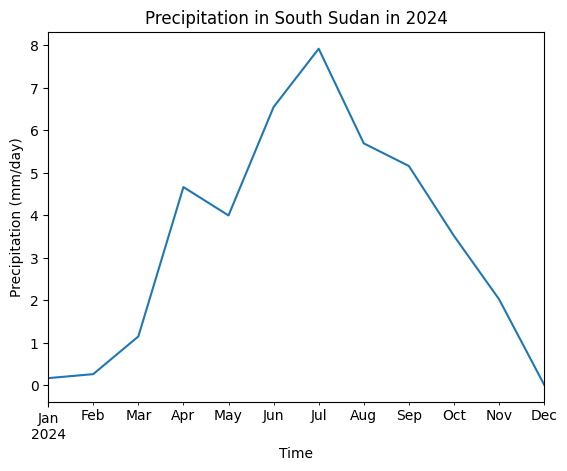

In [15]:
# Subset 2024

time_series_subset = time_series[
    (time_series.index.get_level_values('S').year == 2024)
]

time_series_subset.plot()
plt.xlabel('Time')
plt.ylabel('Precipitation (mm/day)')
plt.title('Precipitation in South Sudan in 2024')
plt.show()